# 📱 Mobile Price Range Classification using Keras and TensorFlow
This project demonstrates how to build a deep learning model to classify mobile phones into price ranges using the Keras API of TensorFlow.


## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

2025-06-18 08:18:34.785507: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750234714.811754     603 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750234714.819428     603 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 📂 Step 2: Load the Dataset

In [ ]:
df = pd.read_csv('mobiles.csv')

In [3]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

## 📊 Exploratory Data Analysis (EDA)
Before building a deep learning model, it's important to understand the structure and characteristics of the dataset.


### 🔹 1. Dataset Overview
- The dataset contains **2,000 rows** and **21 columns**.
- The target variable is `price_range`, which is a **categorical variable** with four classes:
  - `0`: Low cost
  - `1`: Medium cost
  - `2`: High cost
  - `3`: Very high cost

### 🔹 2. Target Distribution

<Axes: title={'center': 'Distribution of Price Ranges'}, xlabel='price_range'>

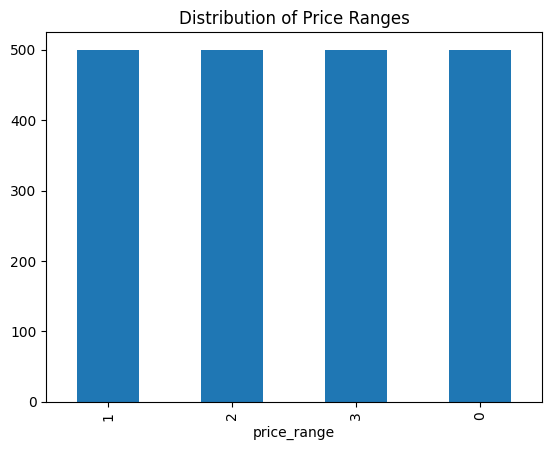

In [5]:
df['price_range'].value_counts().plot(kind='bar', title='Distribution of Price Ranges')

### 🔹 3. Feature Types
- **Numerical Features**: `battery_power`, `ram`, `px_height`, `px_width`, etc.
- **Binary Features**: `blue`, `dual_sim`, `four_g`, `three_g`, `touch_screen`, `wifi`

These features represent various hardware specs and connectivity options of mobile devices.

### 🔹 4. Correlation with Target

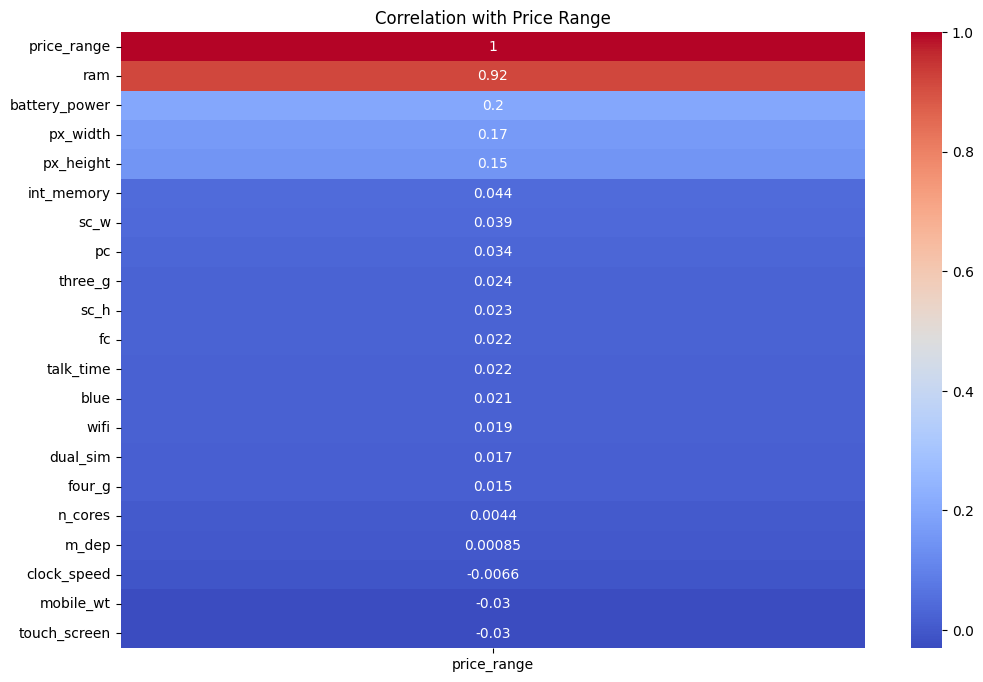

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr[['price_range']].sort_values(by='price_range', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation with Price Range')
plt.show()

### 🔹 5. Outlier and Distribution Check

array([[<Axes: title={'center': 'battery_power'}>,
        <Axes: title={'center': 'ram'}>],
       [<Axes: title={'center': 'px_height'}>,
        <Axes: title={'center': 'px_width'}>]], dtype=object)

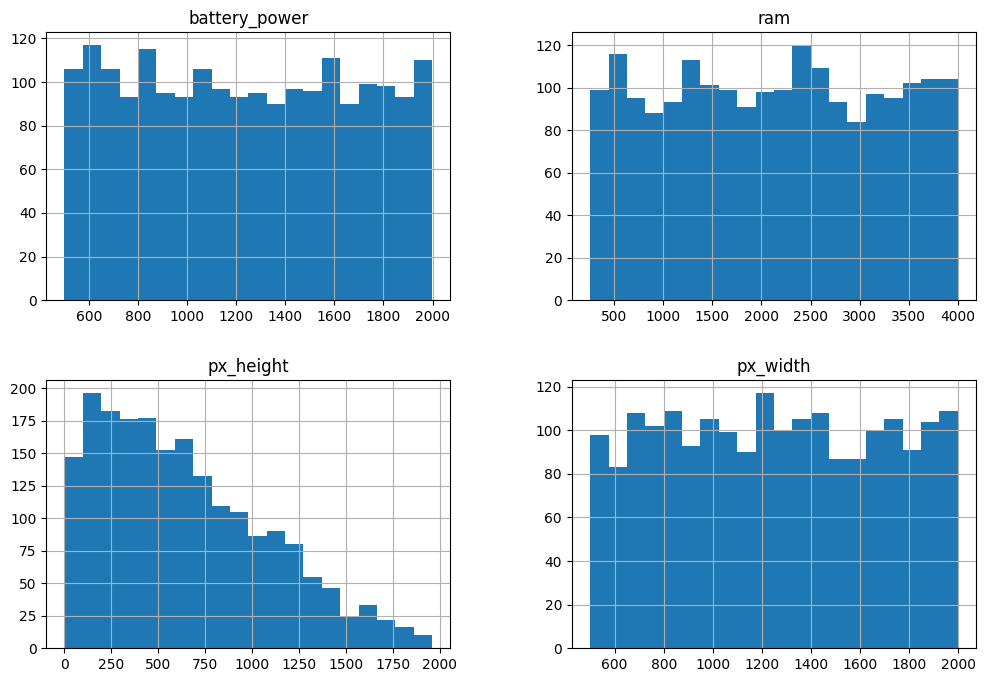

In [7]:
df[['battery_power', 'ram', 'px_height', 'px_width']].hist(figsize=(12, 8), bins=20)

### 🔹 6. Feature Redundancy
- `px_height` and `px_width` are both components of screen resolution.
- `pc` (primary camera) and `fc` (front camera) may correlate with price, but possibly non-linearly.

### 🔹 7. Missing Values

In [8]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

## 🧼 Step 3: Prepare the Data
- Split features and target
- Normalize features
- One-hot encode the target

In [9]:
X = df.drop('price_range', axis=1)
y = df['price_range']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_encoded = to_categorical(y)

## ✂️ Step 4: Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

## 🧠 Step 5: Build the Neural Network

In [11]:
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-18 08:20:22.630428: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## ⚙️ Step 6: Compile the Model

In [13]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## 🏋️ Step 7: Train the Model

In [14]:
history = model.fit(X_train, y_train, validation_split=0.1, epochs=20, batch_size=32)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3309 - loss: 1.4006 - val_accuracy: 0.4875 - val_loss: 1.2166
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5349 - loss: 1.1421 - val_accuracy: 0.5625 - val_loss: 1.0090
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6532 - loss: 0.9054 - val_accuracy: 0.6625 - val_loss: 0.8049
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7844 - loss: 0.6847 - val_accuracy: 0.7625 - val_loss: 0.6444
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8431 - loss: 0.5486 - val_accuracy: 0.8062 - val_loss: 0.5283
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8891 - loss: 0.4329 - val_accuracy: 0.8438 - val_loss: 0.4509
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9151 - loss: 0.3481 - val_accuracy: 0.8562 - val_loss: 0.3888
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9507 - loss: 0.2901 - val_accuracy: 0.8562 - val_loss:

## 📊 Step 8: Evaluate the Model

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9190 - loss: 0.1864  
Test Accuracy: 0.92


## 🔍 Step 9: Predictions and Performance Report

In [16]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96       105
           1       0.87      0.95      0.91        91
           2       0.85      0.89      0.87        92
           3       0.96      0.89      0.93       112

    accuracy                           0.92       400
   macro avg       0.91      0.92      0.91       400
weighted avg       0.92      0.92      0.92       400

Confusion Matrix:
[[ 98   7   0   0]
 [  2  86   3   0]
 [  0   6  82   4]
 [  0   0  12 100]]


## 📈 Optional: Training Curves Visualization

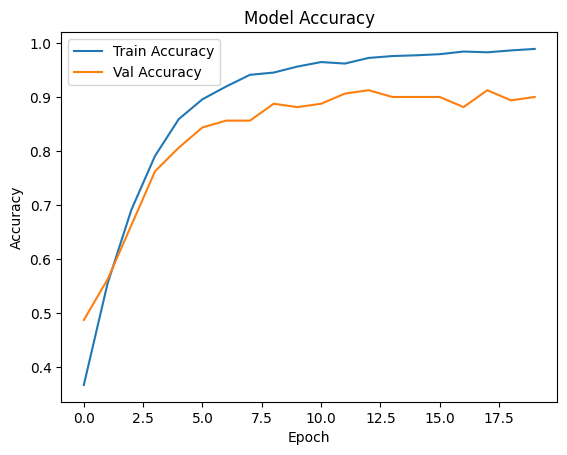

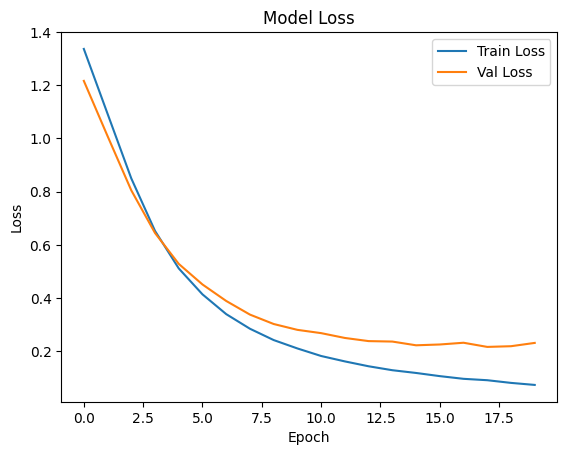

In [19]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()